# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

In [3]:
def plot_modified_df(df_cut):
    """
    Plots the modified DataFrame with adjusted time steps.

    Parameters:
    df_cut (pd.DataFrame): The modified DataFrame with adjusted time steps.

    Returns:
    None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'], label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'], label='Normal Force (Fz)', alpha=0.7)
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Modified Tangential vs Normal Force (Adjusted Timesteps)')
    plt.grid()
    plt.show()

<font size="6">Schieferstein 50°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 470
Average Fx in the averaging interval [740:1210]: 4.806490666139211
Average Fz in the averaging interval [740:1210]: 1.2582636839954564
Maximum Fz in the plotting interval [740:None]: 2.566947428385417 at timestep 1184
Time step where Fx drops below 1: 1210


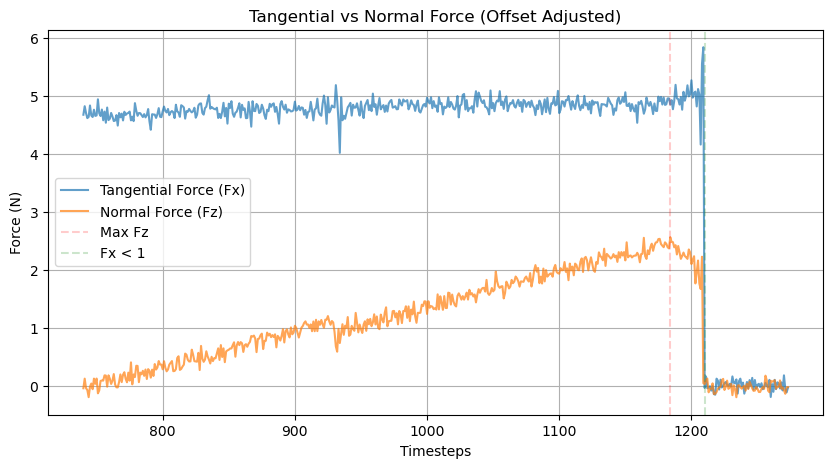

In [17]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240834.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=740, cut_2=None, avg_end=1210, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 948
Average Fx in the averaging interval [1210:2158]: 5.340669797140838
Average Fz in the averaging interval [1210:2158]: 3.024753103779338
Maximum Fz in the plotting interval [1210:None]: 6.2349853515625 at timestep 2135
Time step where Fx drops below 1: 2158


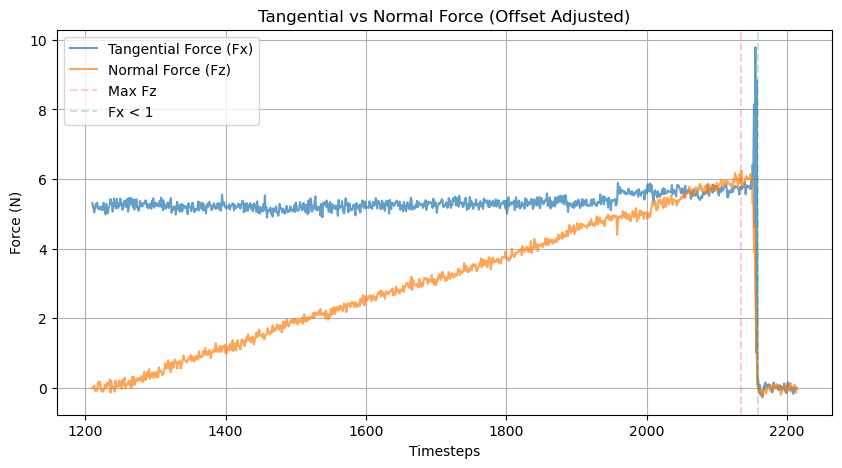

In [23]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240835.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1210, cut_2=None, avg_end=2158, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 1005
Average Fx in the averaging interval [64:1069]: 4.862286576702821
Average Fz in the averaging interval [64:1069]: 1.3804988120918844
Maximum Fz in the plotting interval [64:None]: 2.7479207356770834 at timestep 1037
Time step where Fx drops below 1: 1069


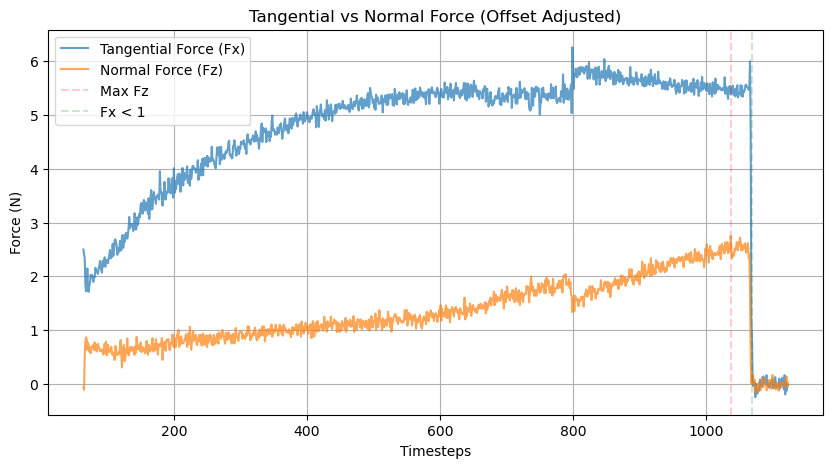

In [30]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240836.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=64, cut_2=None, avg_end=1069, offset_position='end', offset_length=15)

<font size="6">Test 4a: (worked)</font>

Length from cut_1 to avg_end: 197
Average Fx in the averaging interval [676:873]: 4.964384367179548
Average Fz in the averaging interval [676:873]: 0.555766696574926
Maximum Fz in the plotting interval [676:895]: 1.2462239583333334 at timestep 850
Time step where Fx drops below 1: 873


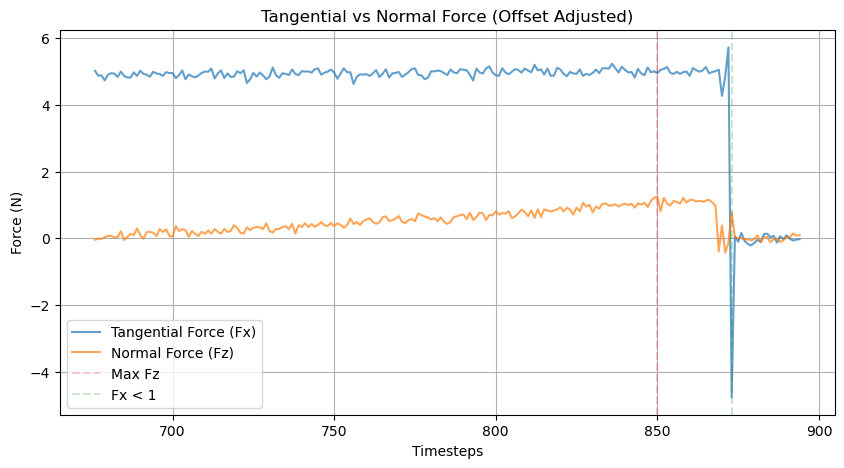

In [66]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240837.csv"
df = pd.read_csv(data)
test_4a, end_4a = plot_forces(df, cut_1=676, cut_2=895, avg_end=873, offset_position='end', offset_length=15)

<font size="6">Test 4b: (partially worked (small normal force))</font>

Length from cut_1 to avg_end: 259
Average Fx in the averaging interval [988:1247]: 0.8207772305266431
Average Fz in the averaging interval [988:1247]: 0.33094099086530726
Maximum Fz in the plotting interval [988:None]: 0.6063313802083333 at timestep 1178
Time step where Fx drops below 0.1: 1247


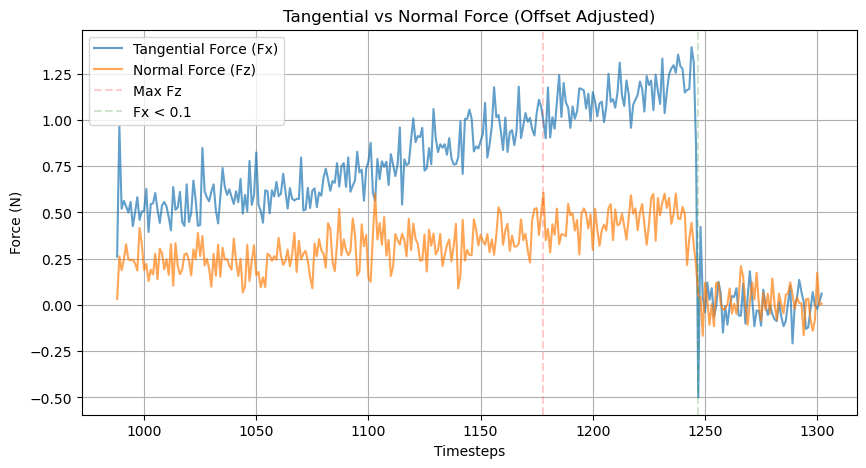

In [67]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240837.csv"
df = pd.read_csv(data)
test_4b, end_4b = plot_forces(df, cut_1=988, cut_2=None, avg_end=1247, offset_position='end', offset_length=15, fx_threshold=0.1)

<font size="6">Test 5a: (worked)</font>

Length from cut_1 to avg_end: 516
Average Fx in the averaging interval [933:1449]: 5.070185154537822
Average Fz in the averaging interval [933:1449]: 1.6220938512521197
Maximum Fz in the plotting interval [933:1470]: 3.3135579427083335 at timestep 1425
Time step where Fx drops below 1: 1449


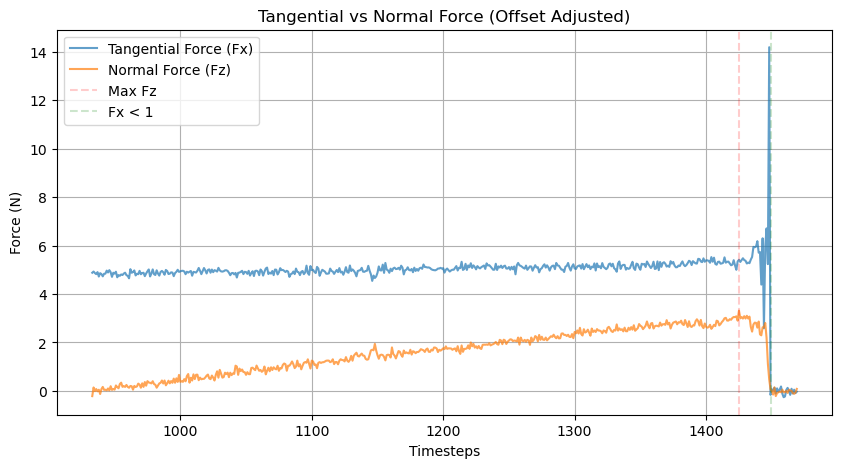

In [68]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240839.csv"
df = pd.read_csv(data)
test_5a, end_5a = plot_forces(df, cut_1=933, cut_2=1470, avg_end=1449, offset_position='end', offset_length=15)

<font size="6">Test 5b: (worked)</font>

Length from cut_1 to avg_end: 599
Average Fx in the averaging interval [1489:2088]: 3.5025000036724685
Average Fz in the averaging interval [1489:2088]: 0.9048584867465742
Maximum Fz in the plotting interval [1489:None]: 2.3626302083333335 at timestep 2071
Time step where Fx drops below 1: 2088


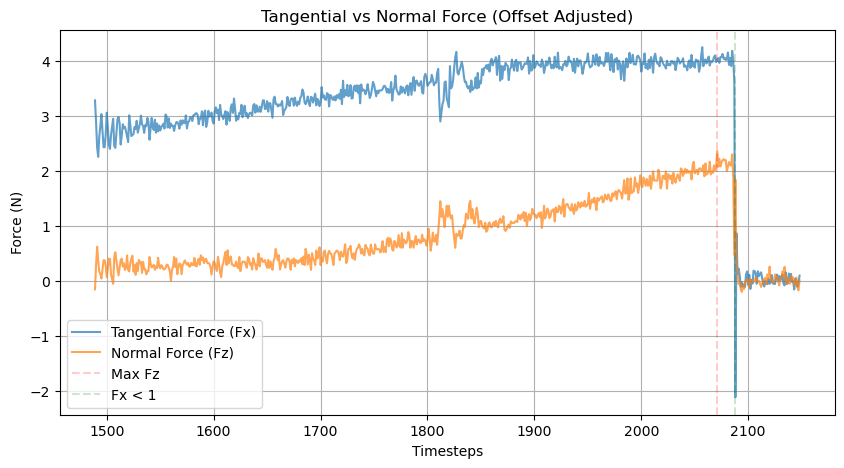

In [83]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240839.csv"
df = pd.read_csv(data)
test_5b, end_5b = plot_forces(df, cut_1=1489, cut_2=None, avg_end=2088, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 437
Average Fx in the averaging interval [795:1232]: 4.93296569875867
Average Fz in the averaging interval [795:1232]: 1.234064749594775
Maximum Fz in the plotting interval [795:None]: 2.5088704427083335 at timestep 1218
Time step where Fx drops below 1: 1232


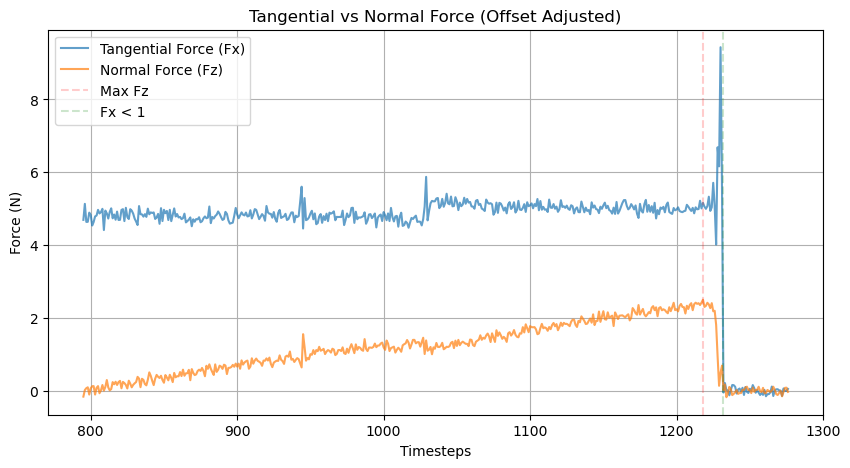

In [89]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240840.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=795, cut_2=None, avg_end=1232, offset_position='end', offset_length=15)

<font size="6">Test 7: (failed)</font>

Average Fx in the averaging interval [None:None]: 2.3682651604723417
Average Fz in the averaging interval [None:None]: -1.8989666072710072
Maximum Fz in the plotting interval [None:None]: 1.6379638671875 at timestep 405
Time step where Fx drops below 1: 0


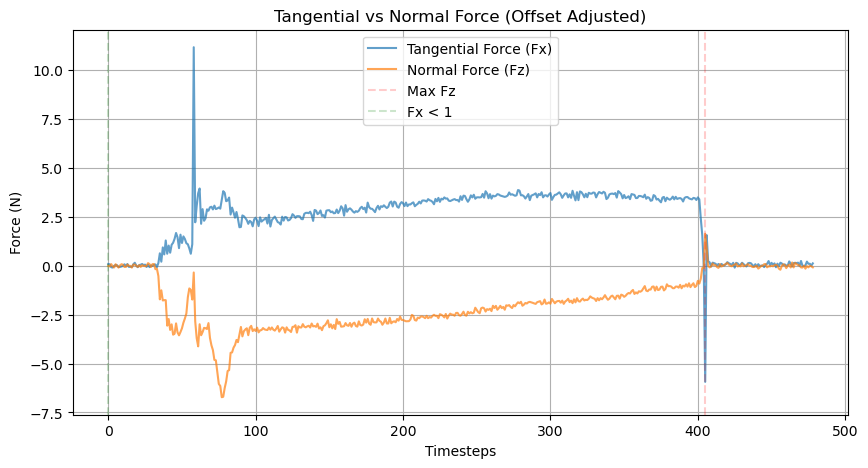

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240841.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 770
Average Fx in the averaging interval [678:1448]: 5.446133417587776
Average Fz in the averaging interval [678:1448]: 1.424686289865733
Maximum Fz in the plotting interval [678:None]: 2.982657877604167 at timestep 1265
Time step where Fx drops below 1: 1448


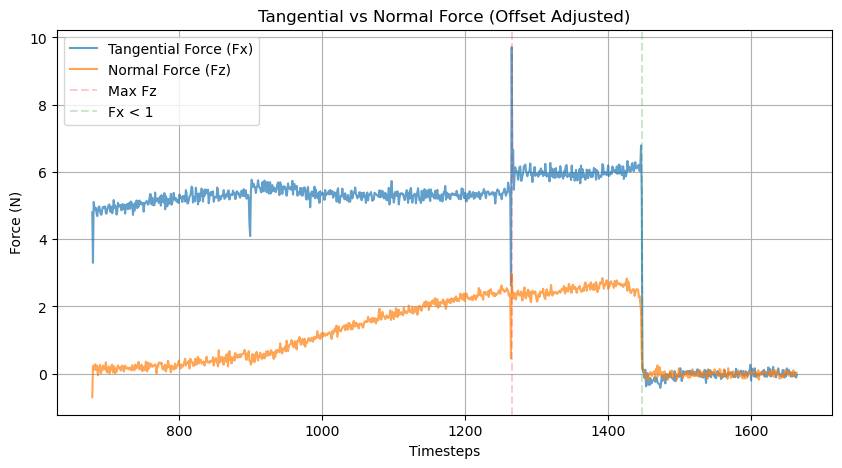

In [98]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240842.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=678, cut_2=None, avg_end=1448, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 845
Average Fx in the averaging interval [75:920]: 4.85648589491609
Average Fz in the averaging interval [75:920]: 1.520086272651627
Maximum Fz in the plotting interval [75:None]: 2.769384765625 at timestep 908
Time step where Fx drops below 1: 920


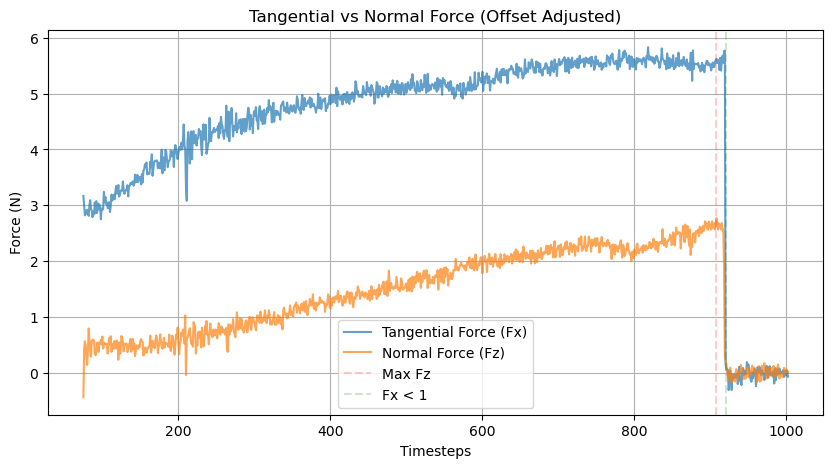

In [106]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240843.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=75, cut_2=None, avg_end=920, offset_position='end', offset_length=15)

<font size="6">Test 10a: (worked)</font>

Length from cut_1 to avg_end: 427
Average Fx in the averaging interval [468:895]: 5.451883747166344
Average Fz in the averaging interval [468:895]: 0.4942119327399248
Maximum Fz in the plotting interval [468:915]: 1.0019083658854167 at timestep 810
Time step where Fx drops below 1: 895


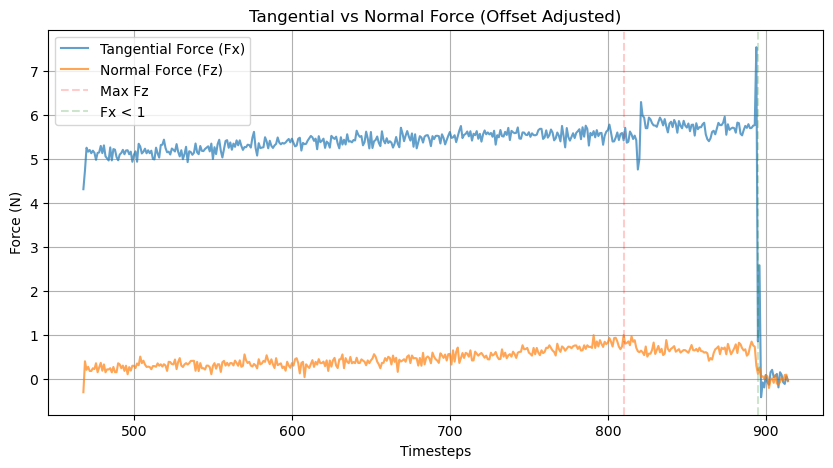

In [117]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240844.csv"
df = pd.read_csv(data)
test_10a, end_10a = plot_forces(df, cut_1=468, cut_2=915, avg_end=895, offset_position='end', offset_length=15)

<font size="6">Test 10b: (worked)</font>

Length from cut_1 to avg_end: 1119
Average Fx in the averaging interval [1330:2449]: 5.457110516954683
Average Fz in the averaging interval [1330:2449]: 2.9536229574222244
Maximum Fz in the plotting interval [1330:None]: 5.268998209635416 at timestep 2416
Time step where Fx drops below 1: 2449


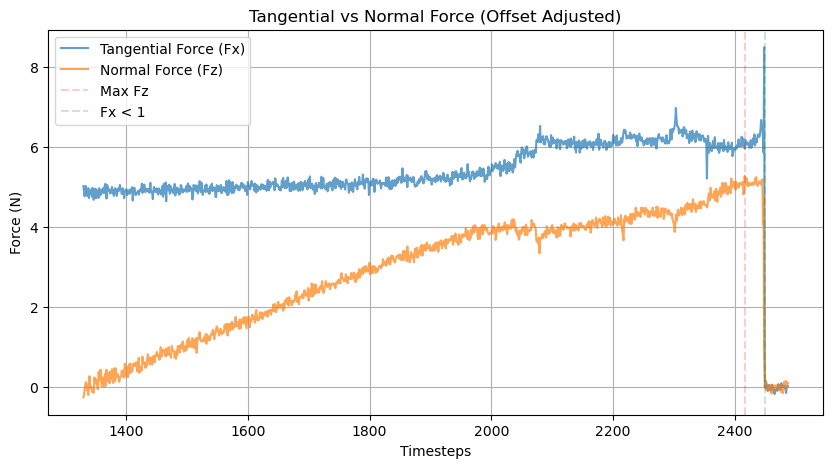

In [122]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_50_5N//log_202405240844.csv"
df = pd.read_csv(data)
test_10b, end_10b = plot_forces(df, cut_1=1330, cut_2=None, avg_end=2449, offset_position='end', offset_length=15)

In [123]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [127]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//50//Schieferstein_50_stats.csv", index=False)

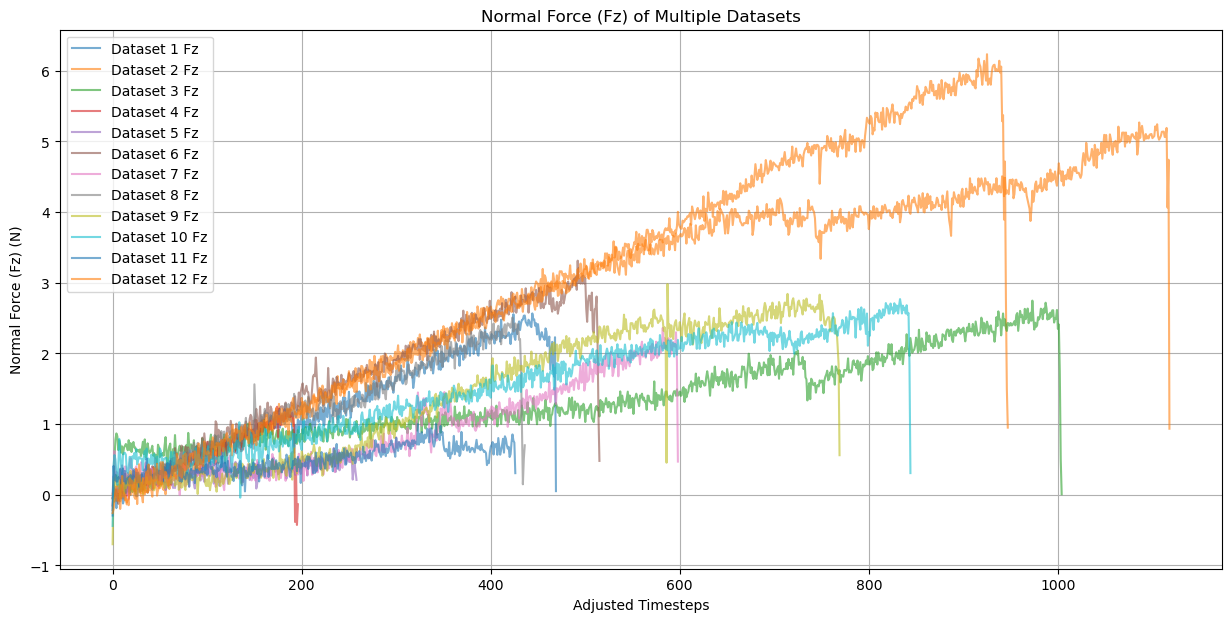

Average of maximum Fz forces: 2.8008680555555556
Standard deviation of maximum Fz forces: 1.5541803967102408
Average of average Fz forces: 1.3919873189649907
Standard deviation of average Fz forces: 0.8208933382513504
Average of average Fx forces: 4.62598942260691
Standard deviation of average Fx forces: 1.2531871803813495


In [128]:
tests = [test_1, test_2, test_3, test_4a, test_4b, test_5a, test_5b, test_6, test_8, test_9, test_10a, test_10b]
ends = [end_1, end_2, end_3, end_4a, end_4b, end_5a, end_5b, end_6, end_8, end_9, end_10a, end_10b]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [129]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//50//Schieferstein_50"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)